In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
import pandas_datareader as pdr            

In [4]:
df = pd.read_csv(r"C:\Users\asus\Downloads\Market.csv")

df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,01-03-1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,01-04-1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,01-05-1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,01-06-1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows: 112457
Columns: 8

Column Names:
Index(['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Missing Values:
Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64


In [6]:
df_nya = df[df["Index"] == "NYA"].copy()

print("NYA data shape:", df_nya.shape)

df_nya.head()         #give me the rows where index=NYA

NYA data shape: (13948, 8)


,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,01-03-1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,01-04-1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,01-05-1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,01-06-1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [7]:
df_nya["Date"] = pd.to_datetime(
    df_nya["Date"],
    format="mixed",                            # bcz python needs to undwrstand the dates properly for sorting and p
    dayfirst=True
)

df_nya = df_nya.sort_values("Date")

df_nya.head()                                      #arrange the data from oldest date to newest date 

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
22,NYA,1966-01-02,529.109985,529.109985,529.109985,529.109985,529.109985,0.0
41,NYA,1966-01-03,517.900024,517.900024,517.900024,517.900024,517.900024,0.0
64,NYA,1966-01-04,515.580017,515.580017,515.580017,515.580017,515.580017,0.0
105,NYA,1966-01-06,491.779999,491.779999,491.779999,491.779999,491.779999,0.0


In [8]:
print("Starting Date:", df_nya["Date"].min())
print("Ending Date:", df_nya["Date"].max())

Starting Date: 1965-12-31 00:00:00
Ending Date: 2021-12-05 00:00:00


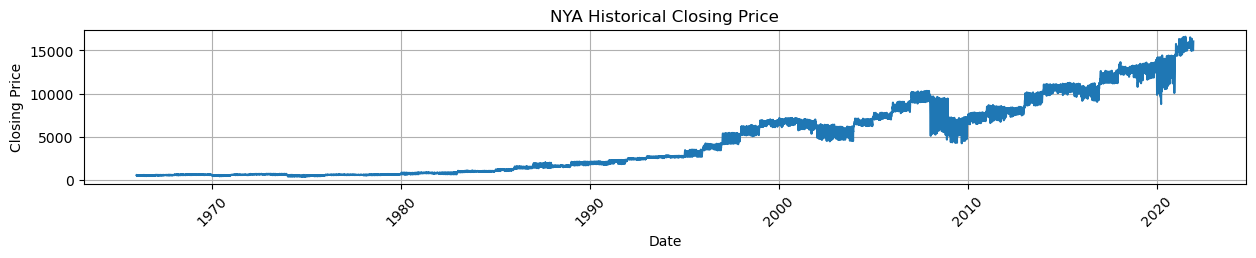

In [9]:
plt.figure(figsize=(15, 2))

plt.plot(df_nya["Date"], df_nya["Close"])

plt.title("NYA Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [10]:
df_nya = df_nya.dropna()              #this row removes containing missing values.

print(df_nya.isnull().sum())             #clean data

Index        0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [11]:
close_prices = df_nya["Close"].values.reshape(-1, 1)

print(close_prices.shape)       #usable data 

(13932, 1)


In [12]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(close_prices)

print(scaled_data[:5])             

[[0.01113857]
 [0.01116443]
 [0.01047427]
 [0.01033144]
 [0.00886616]]


In [13]:
training_size = int(len(scaled_data) * 0.80)

train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

print("Training data:", len(train_data))
print("Testing data:", len(test_data))

Training data: 11145
Testing data: 2787


In [14]:
time_step = 60

X_train = []
y_train = []

for i in range(time_step, len(train_data)):
    X_train.append(train_data[i-time_step:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

print("Final X_train shape:", X_train.shape)

X_train shape: (11085, 60)
y_train shape: (11085,)
Final X_train shape: (11085, 60, 1)


In [15]:
test_inputs = scaled_data[
    training_size - time_step:
]

X_test = []
y_test = []

for i in range(time_step, len(test_inputs)):
    X_test.append(test_inputs[i-time_step:i, 0])
    y_test.append(test_inputs[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (2787, 60, 1)
y_test shape: (2787,)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))

model.add(
    LSTM(
        units=50,
        return_sequences=True
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50,
        return_sequences=True
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=50
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print("Model compiled successfully!")

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 1.3722e-04 - val_loss: 0.0032
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - loss: 1.4241e-04 - val_loss: 0.0023
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - loss: 1.3678e-04 - val_loss: 0.0028
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - loss: 1.3907e-04 - val_loss: 0.0029
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 42s 113ms/step - loss: 1.3448e-04 - val_loss: 0.0030
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - loss: 1.3785e-04 - val_loss: 0.0030
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - loss: 1.3645e-04 - val_loss: 0.0020
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - loss: 1.4088e-04 - val_loss: 0.0032
Epoch 9/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - loss: 1.3375e-04 - val_loss: 0.0032
Epoch 10/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - loss: 1.4060e-04 - val_loss: 0.0030
Epoch 11/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - loss: 1.4341e-04 

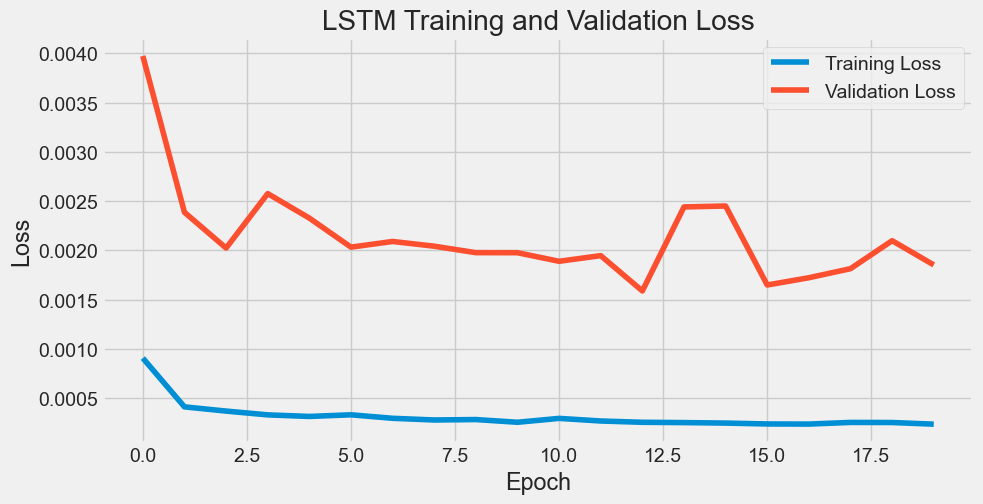

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
predictions = model.predict(X_test)

print(predictions.shape)
predicted_prices = scaler.inverse_transform(predictions)

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)


88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step
(2787, 1)


In [21]:
comparison = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predicted_prices.flatten()
})

comparison.head(29)

,Actual Price,Predicted Price
0,7600.930176,-444.956390
1,7258.020020,-443.959503
2,7174.270020,-442.915802
3,7434.180176,-441.628601
4,7800.660156,-440.391632
5,7234.370117,-439.804321
6,7077.640137,-439.291016
7,7063.830078,-438.363251
8,6959.209961,-436.895966
9,6927.209961,-434.823486


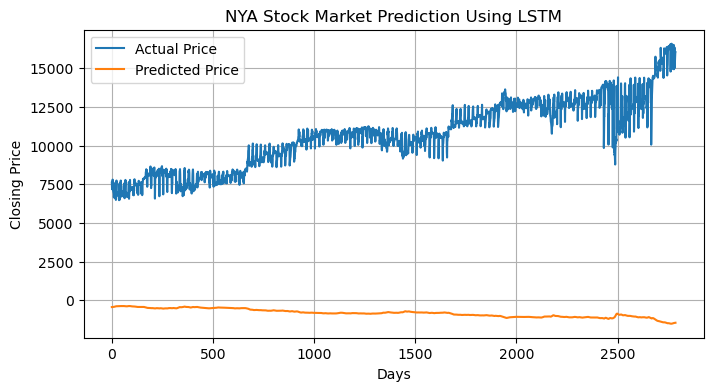

In [22]:
plt.figure(figsize=(8, 4))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predicted_prices,
    label="Predicted Price"
)

plt.title("NYA Stock Market Prediction Using LSTM")

plt.xlabel("Days")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

print("RMSE:", rmse)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

print("MAE:", mae)

RMSE: 11754.36484018558
MAE: 11503.170998931693


In [24]:
last_60_days = scaled_data[-60:]

X_next = []

X_next.append(last_60_days[:, 0])

X_next = np.array(X_next)

X_next = np.reshape(
    X_next,
    (X_next.shape[0], X_next.shape[1], 1)
)

next_prediction = model.predict(X_next)

next_price = scaler.inverse_transform(
    next_prediction
)

print("Predicted Next Closing Price:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted Next Closing Price: -1458.8977
